# For general utility functions

## 0. Import packages

In [1]:
# Data handling
import numpy as np
import pandas as pd
from collections import defaultdict

# Specific functions needed for simulation and other utility uses
from scipy.integrate import solve_ivp
from scipy.special import softmax
from scipy.spatial.distance import euclidean,cosine
from sklearn.decomposition import PCA

# Needed for combinatorics in parameter sweeps
import itertools

# Visualisations
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

## 1. Defining functions

In [2]:
def cosine_similarity(
        u: np.array,
        v: np.array
) -> np.array:
    return 1 - np.array([cosine(u, v_row) for v_row in np.atleast_2d(v)])

In [3]:
def rank_tfs(
        xi_df: pd.DataFrame,
        source_cell: str,
        target_cell: str,
        top_n: int = 5
        ):
    """
    Rank transcription factors by predictivity gap.
    """
    if source_cell not in xi_df.columns:
        raise ValueError(f"Source '{source_cell}' not found. Available: {xi_df.columns.tolist()}")
    if target_cell not in xi_df.columns:
        raise ValueError(f"Target '{target_cell}' not found. Available: {xi_df.columns.tolist()}")

    target_pattern = xi_df[target_cell]
    source_pattern = xi_df[source_cell]

    target_delta = target_pattern - source_pattern

    results = pd.DataFrame({
        "source_expression": source_pattern,
        "target_expression": target_pattern,
        "target_delta": target_delta,
        "global_delta": target_pattern - xi_df.drop(columns=[target_cell]).max(axis=1),
        "direction": target_delta.apply(lambda x: "overexpress" if x > 0.0 else "knockdown")
    }).sort_values("global_delta", ascending=False)

    return results.head(top_n)

In [4]:
def rhs_(
        x: np.array,
        xi: np.array,
        beta: np.float64,
        w: np.array,
        v_star: np.array, #<- modulated v by some callable function to "switch" on/off the overexpression desired
        tau: np.float64 = 1.0
) -> np.array:
    return (v_star + xi.T @ softmax(w + beta * xi @ x) - x) / tau

In [5]:
def simulate(
        x_0: np.array,
        target_pattern: np.array,
        xi: np.array,
        beta: callable,
        w: np.array,
        v: callable,
        tau: np.float64 = 1.0,
        t_max: np.float64 = 50.0,
        n_steps: int = 500,
        convergence_threshold: np.float64 = 9.999e-1
) -> tuple:
    """
    Simulate cell dynamics from an initial state.
    """

    # Define terminal convergence event
    def convergence_event(t: np.float64, y: np.array) -> bool:
        return cosine_similarity(y, target_pattern) - convergence_threshold
    convergence_event.terminal = True

    t_span = (0, t_max)
    t_eval = np.linspace(0, t_max, n_steps)

    sol = solve_ivp(
    lambda t, y: rhs_(y, xi, beta(t), w, v(t), tau),
    t_span,
    x_0,
    t_eval=t_eval,
    method='RK45',
    atol=1e-8,
    rtol=1e-8,
    max_step=0.01,
    events = convergence_event
)

    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    return sol.t, sol.y

In [6]:
def compute_v(
      tf_array: np.array,
      selected_tfs: np.array,
      tf_lookup: dict,
      delta: np.array = None
) -> np.array:
    """
    Construct overexpression vector v.
    """

    try:
        assert delta.shape[0] == selected_tfs.shape[0], \
        f"The length of magnitudes does not match the number of selected TFs: {delta.shape[0]} != {selected_tfs.shape[0]}"
    except:
        # Exception should occur if delta is None -> assign to it the vector of ones
        delta = np.ones_like(selected_tfs, dtype = np.float64)

    v = np.zeros_like(tf_array, dtype = np.float64)

    for indx, tf in enumerate(selected_tfs):
        if tf in tf_array:
            v[tf_lookup[tf]] = delta[indx]
        else:
            print(f"Warning: {tf} not found in TF list - it has not been included as a result")

    return v

In [7]:
def identify_cell_type(
        x: np.array,
        xi: np.array,
        cell_types: np.array
) -> tuple:
    """
    Use cosine similarity to determine most similar cell type of those listed/included.
    """
    similarities = dict(zip(cell_types, cosine_similarity(x, xi)))

    best = max(similarities, key=similarities.get)
    return best, similarities[best]

In [8]:
def test_setting(
        xi_df: pd.DataFrame,
        source: str,
        target: str,
        beta: callable,
        v_modulation: callable = (lambda t: 1.0 * (10 <= t <= 15)),
        delta: np.float64 = 1.0,
        tau: np.float64 = 1.0,
        top_n: int = 5,
        t_max: np.float64 = 50.0,
        n_steps: int = 500
) -> tuple:
    """
    Full reprogramming simulation pipeline.
    """

    #===================================================================================================================
    # 0. Split out data from df

    # Transcription Factors
    transcription_factors = xi_df.columns.to_numpy()
    tf_lookup = dict(zip(transcription_factors, np.arange(n_tfs := len(transcription_factors))))
    tf_index = lambda tf: tf_lookup[tf]

    # Cell Types
    cell_types = xi_df.index.to_numpy()
    cell_lookup = dict(zip(cell_types, np.arange(n_cells := len(cell_types))))
    cell_index = lambda cell: cell_lookup[cell]

    # Xi entries
    xi = xi_df.values

    #===================================================================================================================
    # 1. Find continuous predictivity gap for chosen source and target cells

    rankings = rank_tfs(xi_df.T, source, target, top_n = top_n)
    top_tfs = rankings.index.to_numpy()

    print(f"Top {top_n} TFs for {source} -> {target}: {', '.join(str(tf) for tf in top_tfs)}")

    #===================================================================================================================
    # Step 2 — construct v vectors - for now assume to be magnitude 1 in each entry

    w = np.zeros_like(cell_types, dtype = np.float64)
    v = compute_v(transcription_factors, top_tfs, tf_lookup, delta * np.ones(top_n))

    #===================================================================================================================
    # Step 3 — impose initial condition

    x_0 = xi[cell_lookup[source]]

    #===================================================================================================================
    # Step 4 — simulate baseline

    t, x = simulate(x_0, xi[cell_lookup[target]], xi, beta, w, lambda t: v * v_modulation(t),
                    tau, t_max, n_steps)

    return *identify_cell_type(x[:, -1], xi, cell_types), t[-1]

In [9]:
xi_df = pd.read_csv("FACS_Xi_matrix.csv", index_col = 0)

In [11]:
t, x, final_time = test_setting(
    xi_df,
    "T cell",
    "basal cell",
    lambda t: 50.0,
    top_n = 3,
    delta = 3.0,
    t_max = 50.0,
    n_steps = 500
)

Top 3 TFs for T cell -> basal cell: Egr2, Runx1, Etv2


## 2. Visualisation code

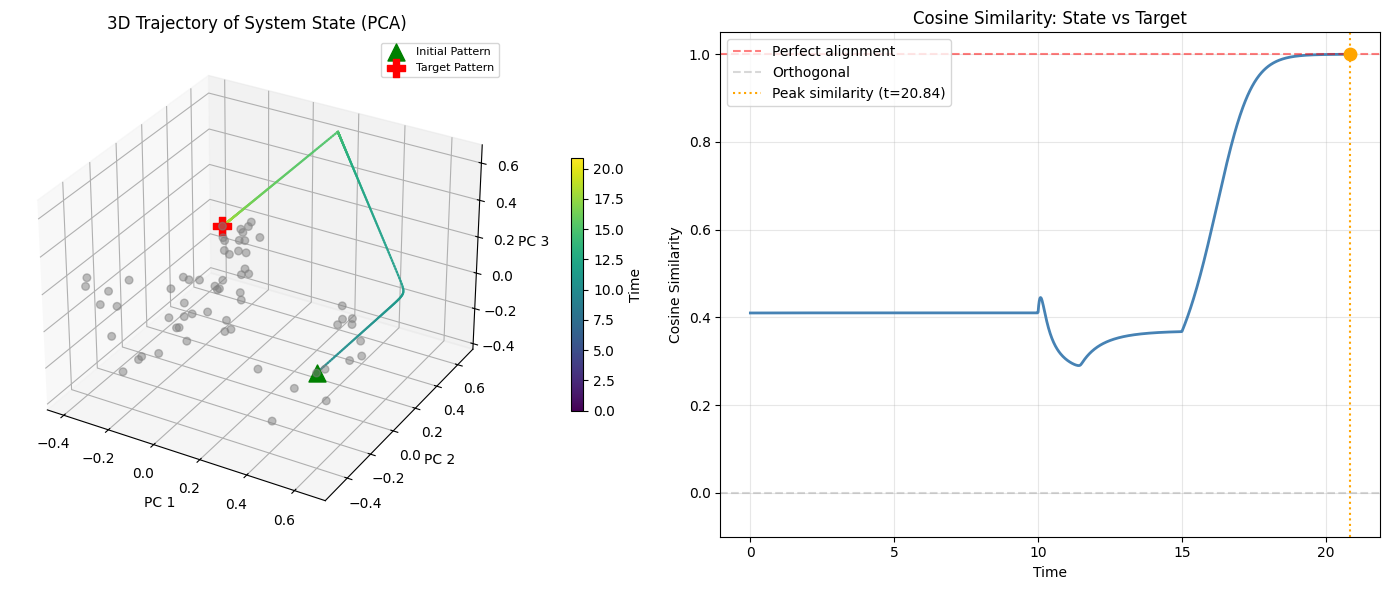

Peak cosine similarity: 0.9999 at t=20.844
Final cosine similarity: 0.9999


In [ ]:
# Extract the solution
solution_trajectory = x.T  # (n_time_points, n_features)

# Apply PCA to reduce dimensions to 3
pca = PCA(n_components=3)
xi_projected      = pca.fit_transform(xi_df.values)
projected_trajectory = pca.transform(solution_trajectory)

initial_projected = pca.transform(source_pattern.reshape(1, -1))
target_projected  = pca.transform(target_pattern.reshape(1, -1))
#xi_projected      = pca.transform(xi_df.values)

# Cosine similarity of trajectory state vs target at each time point
cos_sim = cosine_similarity(target_pattern, solution_trajectory).flatten()

# ── Figure with two panels ──────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))

# ── Left: 3D trajectory ─────────────────────────────────────────────────────
ax3d = fig.add_subplot(121, projection='3d')

# Colour trajectory by time
t_norm = plt.Normalize(t.min(), t.max())
cmap   = plt.cm.viridis

for i in range(len(projected_trajectory) - 1):
    color = cmap(t_norm(t[i]))
    ax3d.plot(projected_trajectory[i:i+2, 0],
              projected_trajectory[i:i+2, 1],
              projected_trajectory[i:i+2, 2],
              color=color, linewidth=1.5, alpha=0.8)

# Cell type attractors
ax3d.scatter(xi_projected[:, 0], xi_projected[:, 1], xi_projected[:, 2],
             color='grey', s=30, alpha=0.5, zorder=1)

# Initial / target markers
ax3d.scatter(*initial_projected[0], color='green', marker='^', s=150,
             label='Initial Pattern', zorder=5)
ax3d.scatter(*target_projected[0],  color='red',   marker='P', s=150,
             label='Target Pattern',  zorder=5)

# Colourbar for time
sm = plt.cm.ScalarMappable(cmap=cmap, norm=t_norm)
sm.set_array([])
plt.colorbar(sm, ax=ax3d, shrink=0.5, pad=0.1, label='Time')

ax3d.set_title('3D Trajectory of System State (PCA)')
ax3d.set_xlabel('PC 1'); ax3d.set_ylabel('PC 2'); ax3d.set_zlabel('PC 3')
ax3d.legend(fontsize=8)

# ── Right: Cosine similarity over time ──────────────────────────────────────
ax2 = fig.add_subplot(122)

ax2.plot(t, cos_sim, color='steelblue', linewidth=2)
ax2.axhline(1.0, color='red',   linestyle='--', alpha=0.5, label='Perfect alignment')
ax2.axhline(0.0, color='grey',  linestyle='--', alpha=0.3, label='Orthogonal')

# Mark where cosine similarity is maximised
peak_idx = np.argmax(cos_sim)
ax2.axvline(t[peak_idx], color='orange', linestyle=':', linewidth=1.5,
            label=f'Peak similarity (t={t[peak_idx]:.2f})')
ax2.scatter(t[peak_idx], cos_sim[peak_idx],
            color='orange', zorder=5, s=80)

ax2.set_title('Cosine Similarity: State vs Target')
ax2.set_xlabel('Time')
ax2.set_ylabel('Cosine Similarity')
ax2.set_ylim(-0.1, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Peak cosine similarity: {cos_sim[peak_idx]:.4f} at t={t[peak_idx]:.3f}")
print(f"Final cosine similarity: {cos_sim[-1]:.4f}")

## 3. Parameter sweeping

In [12]:
np.array(list(itertools.combinations(np.array([0, 1, 2]), 2)))

array([[0, 1],
       [0, 2],
       [1, 2]])

In [ ]:
# 1. Specific choices of TFs
# 2. Number of TFs
# 3. Magnitude/amount to express TFs
# 4. Choice of v modulation
# 5. Choice of beta + annealing
# 6. Choice of w

In [ ]:
sweep_settings = {
    # Whether the specific choice of TF should have predicitivity gap (from target) over ONLY the
    # source/initial pattern OR over ALL patterns. There are some questions here as it relates to
    # page 72 of lecture notes (overexpressing foxa1?)
    "tf_selection": ["only", "all"],
    # The total number of TFs to overexpress (for now capping this at 4)
    "tf_number": np.arange(1,4),
    #
    "delta_magnitude": np.arange(0.5,5.5, 0.5),
    "v_modulation": [lambda t: 1.0 * (10 <= t <= 15)],
    "beta": [lambda t: 10.0, lambda t: 20.0, lambda t: 50.0]
}

# !! HERE

In [ ]:
keys = list(sweep_settings.keys())
values = list(sweep_settings.values())

all_combinations = []
for combo_values in itertools.product(*values):
    combination_dict = dict(zip(keys, combo_values))
    all_combinations.append(combination_dict)

print(f"Total number of combinations: {len(all_combinations)}")

Total number of combinations: 180
{'tf_selection': 'only', 'tf_number': np.int64(1), 'delta_magnitude': np.float64(0.5), 'v_modulation': <function <lambda> at 0x7a74c012cae0>, 'beta': <function <lambda> at 0x7a74c012c4a0>}
{'tf_selection': 'only', 'tf_number': np.int64(1), 'delta_magnitude': np.float64(0.5), 'v_modulation': <function <lambda> at 0x7a74c012cae0>, 'beta': <function <lambda> at 0x7a74c012ca40>}
{'tf_selection': 'only', 'tf_number': np.int64(1), 'delta_magnitude': np.float64(0.5), 'v_modulation': <function <lambda> at 0x7a74c012cae0>, 'beta': <function <lambda> at 0x7a74c012c900>}
{'tf_selection': 'only', 'tf_number': np.int64(1), 'delta_magnitude': np.float64(1.0), 'v_modulation': <function <lambda> at 0x7a74c012cae0>, 'beta': <function <lambda> at 0x7a74c012c4a0>}
{'tf_selection': 'only', 'tf_number': np.int64(1), 'delta_magnitude': np.float64(1.0), 'v_modulation': <function <lambda> at 0x7a74c012cae0>, 'beta': <function <lambda> at 0x7a74c012ca40>}
{'tf_selection': 'onl

In [ ]:
def sweep_test_settings(
        sweep_settings: dict,
        xi_df: pd.DataFrame,
        source: str,
        target: str,
        tau: np.float64 = 1.0,
        t_max: np.float64 = 50.0,
        nsteps: int = 500
) -> pd.DataFrame:
    """
    Sweeping function through the simulation pipeline.
    """

    #===================================================================================================================
    # 0. Split out data from df

    # Transcription Factors
    transcription_factors = xi_df.columns.to_numpy()
    tf_lookup = dict(zip(transcription_factors, np.arange(n_tfs := len(transcription_factors))))
    tf_index = lambda tf: tf_lookup[tf]

    # Cell Types
    cell_types = xi_df.index.to_numpy()
    cell_lookup = dict(zip(cell_types, np.arange(n_cells := len(cell_types))))
    cell_index = lambda cell: cell_lookup[cell]

    # Xi entries
    xi = xi_df.values

    #===================================================================================================================
    # 1. Find continuous predictivity gap for chosen source and target cells

    rankings = rank_tfs(xi_df.T, source, target, top_n = top_n)
    top_tfs = rankings.index.to_numpy()

    print(f"Top {top_n} TFs for {source} -> {target}: {', '.join(str(tf) for tf in top_tfs)}")

    #===================================================================================================================
    # Step 2 — construct v vectors - for now assume to be magnitude 1 in each entry

    w = np.zeros_like(cell_types, dtype = np.float64)
    v = compute_v(transcription_factors, top_tfs, tf_lookup, delta * np.ones(top_n))

    #===================================================================================================================
    # Step 3 — impose initial condition

    x_0 = xi[cell_lookup[source]]

    #===================================================================================================================
    # Step 4 — simulate baseline

    t, x = simulate(x_0, xi[cell_lookup[target]], xi, beta, w, lambda t: v * v_modulation(t),
                    tau, t_max, n_steps)

    return *identify_cell_type(x[:, -1], xi, cell_types), t[-1]

10.0